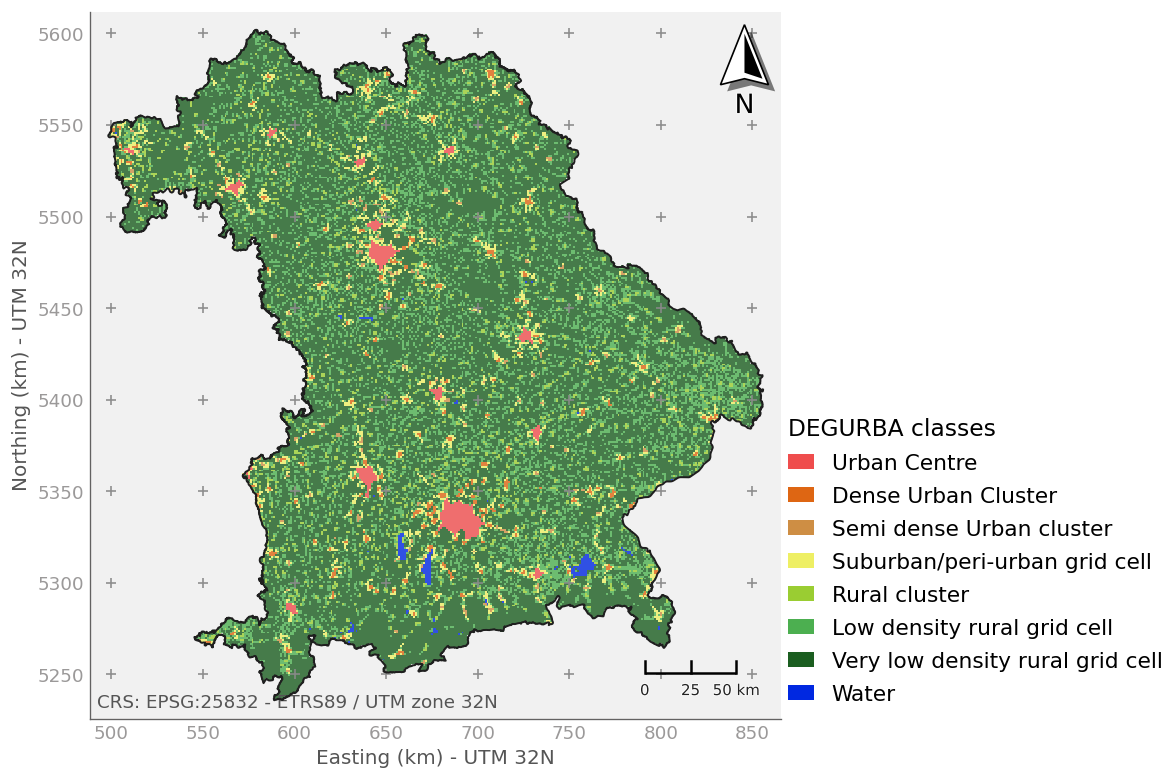

Raster CRS:  EPSG:25832
Saved map:   C:\Users\agz90fk\Documents\Masterarbeit\03_Daten\Output\Figures\degurba\degurba_map.jpg


In [14]:
"""
DEGURBA map for Bavaria.
Template style with grid, north arrow, scale bar, and categorical legend.
"""

import math
from pathlib import Path

import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
import rasterio
import rasterio.crs as rcrs
from matplotlib.colors import BoundaryNorm, ListedColormap
from matplotlib.patches import Patch
from matplotlib.ticker import FuncFormatter
from rasterio.mask import mask
from rasterio.warp import Resampling, calculate_default_transform
from rasterio.warp import reproject as warp_reproject

try:
    from matplotlib_map_utils import north_arrow, scale_bar
    HAS_MMU = True
except Exception:
    HAS_MMU = False

plt.rcParams.update({
    "figure.dpi": 120,
    "savefig.dpi": 300,
    "font.size": 13,
    "axes.titlesize": 19,
    "axes.labelsize": 13,
    "legend.fontsize": 13,
    "legend.title_fontsize": 14,
    "axes.edgecolor": "#333333",
    "axes.linewidth": 0.8,
})


degurba_colors = {
    130: {"class": "Urban Centre",                      "color": "#EF4D4D"},
    223: {"class": "Dense Urban Cluster",               "color": "#DE6613"},
    222: {"class": "Semi dense Urban cluster",          "color": "#CE8E44"},
    221: {"class": "Suburban/peri-urban grid cell",     "color": "#EEEF64"},
    313: {"class": "Rural cluster",                     "color": "#9ACD32"},  # hellgrün
    312: {"class": "Low density rural grid cell",       "color": "#4CAF50"},  # mittelgrün
    311: {"class": "Very low density rural grid cell",  "color": "#1B5E20"},  # dunkelgrün
    310: {"class": "Water",                             "color": "#0028E1"},

}

# ---------------------------------------------------------------------------
# Paths and config
# ---------------------------------------------------------------------------
PATH_LANDKREISE = r"C:\Users\agz90fk\Documents\Masterarbeit\03_Daten\Input\Verwaltungsgebiete\vg250-ew_12-31.utm32s.gpkg.ebenen\vg250-ew_ebenen_1231\DE_VG250.gpkg"
LAYER_LANDKREISE = "v_vg250_krs"
PATH_DEGURBA = r"C:\Users\agz90fk\Documents\Masterarbeit\03_Daten\Output\DatasetSpecific\DEGURBA\DEGURBA_L2_bayern.tif"
OUTPUT_DIR = Path(r"C:\Users\agz90fk\Documents\Masterarbeit\03_Daten\Output\Figures\degurba")
OUTPUT_MAP = OUTPUT_DIR / "degurba_map.jpg"

COL_ARS = "Regionalschlüssel_ARS"
BAYERN_PREFIX = "09"
TARGET_CRS = "EPSG:25832"
CRS_NOTE = "CRS: EPSG:25832 - ETRS89 / UTM zone 32N"
GRID_STEP_M = 50000
MAP_PADDING_M = 10000


# ---------------------------------------------------------------------------
# Helper functions
# ---------------------------------------------------------------------------
def add_matplotlib_grid(ax, bounds, step=GRID_STEP_M):
    minx, miny, maxx, maxy = bounds
    x_start = math.ceil(minx / step) * step
    x_end   = math.floor(maxx / step) * step
    y_start = math.ceil(miny / step) * step
    y_end   = math.floor(maxy / step) * step

    x_major = [x_start + i * step for i in range(int((x_end - x_start) / step) + 1)] if x_start <= x_end else []
    y_major = [y_start + i * step for i in range(int((y_end - y_start) / step) + 1)] if y_start <= y_end else []

    ax.set_xticks(x_major)
    ax.set_yticks(y_major)
    ax.xaxis.set_major_formatter(FuncFormatter(lambda x, _: f"{int(round(x / 1000))}"))
    ax.yaxis.set_major_formatter(FuncFormatter(lambda y, _: f"{int(round(y / 1000))}"))

    if x_major and y_major:
        x_pts = [xv for xv in x_major for _ in y_major]
        y_pts = [yv for _ in x_major for yv in y_major]
        ax.scatter(x_pts, y_pts, marker="+", s=30, linewidths=1.0,
                   color="#8a8a8a", alpha=0.95, zorder=4, clip_on=True)

    ax.tick_params(axis="both", which="major", labelsize=11, length=0, colors="#9B9999")


def add_north_arrow(ax):
    if HAS_MMU:
        north_arrow(
            ax=ax,
            location="upper right",
            size="md",
            rotation={"degrees": 0},
            aob={
                "bbox_to_anchor": (0.985, 0.985),
                "bbox_transform": ax.transAxes,
                "pad": 0.06, "borderpad": 0.06,
                "facecolor": "none", "edgecolor": "none",
                "alpha": 1.0, "frameon": False,
            },
        )
        return

    ax.annotate(
        "",
        xy=(0.945, 0.960), xytext=(0.945, 0.880),
        xycoords="axes fraction", textcoords="axes fraction",
        arrowprops=dict(arrowstyle="-|>", color="#222222", linewidth=1.4, shrinkA=0, shrinkB=0),
        zorder=10,
    )
    ax.text(0.945, 0.972, "N", transform=ax.transAxes,
            ha="center", va="bottom", fontsize=14, fontweight="bold",
            color="#222222", zorder=10)


def add_scale_bar(ax):
    if HAS_MMU:
        scale_bar(
            ax=ax, location="lower right", size="xs", style="ticks",
            bar={"projection": TARGET_CRS, "unit": "km", "max": 50,
                 "major_div": 2, "minor_div": 1, "minor_type": "none", "reverse": False},
            labels={"labels": ["0", "25", "50"], "style": "major", "loc": "below", "fontsize": 9},
            units={"loc": "text", "label": "km"},
            text={"fontfamily": "sans-serif", "fontsize": 9, "textcolor": "#222222"},
            aob={"pad": 0.0, "borderpad": 1.0, "facecolor": "none",
                 "edgecolor": "none", "alpha": 1.0, "frameon": False},
        )
        return

    x0, x1 = ax.get_xlim()
    y0, y1 = ax.get_ylim()
    span_x, span_y = x1 - x0, y1 - y0
    bar_len, seg_len = 50_000, 25_000
    xs = x1 - span_x * 0.35
    ys = y0 + span_y * 0.060
    ax.plot([xs, xs + bar_len], [ys, ys], color="#222222", linewidth=1.3, zorder=8)
    tick_h = span_y * 0.006
    for x in [xs, xs + seg_len, xs + bar_len]:
        ax.plot([x, x], [ys - tick_h, ys + tick_h], color="#222222", linewidth=1.0, zorder=8)
    ty = ys + span_y * 0.011
    ax.text(xs,            ty, "0",     ha="center", va="bottom", fontsize=9, color="#222222", zorder=8)
    ax.text(xs + seg_len,  ty, "25",    ha="center", va="bottom", fontsize=9, color="#222222", zorder=8)
    ax.text(xs + bar_len,  ty, "50 km", ha="center", va="bottom", fontsize=9, color="#222222", zorder=8)


def add_scientific_frame(ax, gdf_base):
    ax.set_facecolor("#f1f1f1")
    minx, miny, maxx, maxy = gdf_base.total_bounds
    bounds = (minx - MAP_PADDING_M, miny - MAP_PADDING_M,
              maxx + MAP_PADDING_M, maxy + MAP_PADDING_M)
    ax.set_xlim(bounds[0], bounds[2])
    ax.set_ylim(bounds[1], bounds[3])
    ax.margins(0)
    add_matplotlib_grid(ax, bounds)
    ax.set_xlim(bounds[0], bounds[2])
    ax.set_ylim(bounds[1], bounds[3])
    ax.set_autoscale_on(False)

    ax.set_xlabel("Easting (km) - UTM 32N", fontsize=12, color="#555555")
    ax.set_ylabel("Northing (km) - UTM 32N", fontsize=12, color="#555555")
    ax.text(0.01, 0.01, CRS_NOTE, transform=ax.transAxes,
            ha="left", va="bottom", fontsize=11, color="#555555")

    for side in ["top", "right"]:
        ax.spines[side].set_visible(False)
    for side in ["left", "bottom"]:
        ax.spines[side].set_visible(True)
        ax.spines[side].set_color("#636262")
        ax.spines[side].set_linewidth(0.8)


# ---------------------------------------------------------------------------
# Load Bavaria boundary
# ---------------------------------------------------------------------------
gdf_lk = gpd.read_file(PATH_LANDKREISE, layer=LAYER_LANDKREISE)
ars_col = COL_ARS if COL_ARS in gdf_lk.columns else next(
    (c for c in gdf_lk.columns if "ARS" in c or "ars" in c), None)
if ars_col is None:
    raise ValueError("No ARS column found in Landkreis layer.")

gdf_lk = gdf_lk[gdf_lk[ars_col].astype(str).str.startswith(BAYERN_PREFIX)].copy()
if gdf_lk.crs is None or str(gdf_lk.crs) != TARGET_CRS:
    gdf_lk = gdf_lk.to_crs(TARGET_CRS)
gdf_bayern = gdf_lk[["geometry"]].dissolve().reset_index(drop=True)


# ---------------------------------------------------------------------------
# Load and prepare DEGURBA raster
# ---------------------------------------------------------------------------
class_codes  = list(degurba_colors.keys())
class_colors = [degurba_colors[c]["color"] for c in class_codes]
cmap = ListedColormap(class_colors)
norm = BoundaryNorm(np.arange(-0.5, len(class_codes) + 0.5, 1), cmap.N)

with rasterio.open(PATH_DEGURBA) as src:
    raster_crs = src.crs
    geoms = [geom.__geo_interface__ for geom in gdf_bayern.to_crs(raster_crs).geometry]
    raster_data, raster_transform = mask(src, geoms, crop=True, nodata=0)

raw = raster_data[0].astype(np.float32)
raw[raw == 0] = np.nan  # nodata -> transparent

# Reproject to TARGET_CRS if needed so the extent aligns with the map axes
tgt_crs = rcrs.CRS.from_string(TARGET_CRS)
if not raster_crs == tgt_crs:
    h_src, w_src = raw.shape
    dst_transform, w_dst, h_dst = calculate_default_transform(
        raster_crs, tgt_crs, w_src, h_src,
        left=raster_transform.c,
        bottom=raster_transform.f + raster_transform.e * h_src,
        right=raster_transform.c + raster_transform.a * w_src,
        top=raster_transform.f,
    )
    dst_raw = np.full((h_dst, w_dst), np.nan, dtype=np.float32)
    warp_reproject(
        source=raw, destination=dst_raw,
        src_transform=raster_transform, src_crs=raster_crs,
        dst_transform=dst_transform,   dst_crs=tgt_crs,
        resampling=Resampling.nearest,
        src_nodata=np.nan, dst_nodata=np.nan,
    )
    raw = dst_raw
    raster_transform = dst_transform

# Map class codes to 0-based indices for the ListedColormap
class_idx = np.full(raw.shape, np.nan, dtype=np.float32)
for i, code in enumerate(class_codes):
    class_idx[raw == code] = i

# Downsample for display if raster is very large
h, w = raw.shape
max_dim = 2000
if max(h, w) > max_dim:
    step = int(np.ceil(max(h, w) / max_dim))
    class_idx = class_idx[::step, ::step]

# Spatial extent in TARGET_CRS coordinates
left   = raster_transform.c
top    = raster_transform.f
right  = left + raster_transform.a * w
bottom = top  + raster_transform.e * h   # e is negative -> bottom < top


# ---------------------------------------------------------------------------
# Plot
# ---------------------------------------------------------------------------
fig, ax = plt.subplots(figsize=(8.6, 9.4))
fig.subplots_adjust(right=0.74, left=0.07, top=0.92, bottom=0.08)

minx, miny, maxx, maxy = gdf_bayern.total_bounds
bounds = (minx - MAP_PADDING_M, miny - MAP_PADDING_M,
          maxx + MAP_PADDING_M, maxy + MAP_PADDING_M)
ax.set_xlim(bounds[0], bounds[2])
ax.set_ylim(bounds[1], bounds[3])

# DEGURBA raster as basemap
ax.imshow(
    class_idx,
    cmap=cmap, norm=norm,
    extent=(left, right, bottom, top),
    interpolation="nearest",
    zorder=2,
    alpha = 0.8
)

# Bavaria boundary
gdf_bayern.plot(ax=ax, facecolor="none", edgecolor="#1f1f1f", linewidth=1.2, zorder=6)

# Categorical legend
legend_handles = [
    Patch(facecolor=degurba_colors[c]["color"], edgecolor="none",
          label=degurba_colors[c]["class"])
    for c in class_codes
]
# ax.legend(
#     handles=legend_handles,
#     title="DEGURBA classes",
#     loc="center left",
#     bbox_to_anchor=(1.01, 0.02),
#     frameon=False,
#     fontsize=13,
#     title_fontsize=11,
#     labelspacing=0.6,
# )
legend = ax.legend(
    handles=legend_handles,
    title="DEGURBA classes",
    loc="lower left",
    bbox_to_anchor=(1.01, 0.02),
    borderaxespad=0.0,
    frameon=False,
    fontsize=13,
    title_fontsize=14,
    handlelength=1.2,
    labelspacing=0.6,
    borderpad=0.0,
)

legend.get_title().set_ha("left")
legend._legend_box.align = "left"

add_north_arrow(ax)
add_scale_bar(ax)
add_scientific_frame(ax, gdf_bayern)

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
plt.savefig(OUTPUT_MAP, bbox_inches="tight", facecolor="white", format="jpg")
plt.show()

print(f"Raster CRS:  {raster_crs}")
print(f"Saved map:   {OUTPUT_MAP}")
